# Validation Organ Mask Viewer
Visualize validation T2 volumes with inferred multi-class organ masks (TZ/PZ) using a trained checkpoint (fold0 exp-020).


In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
repo_root = os.path.abspath("..") if os.getcwd().endswith("notebooks") else os.path.abspath(".")
if os.getcwd().endswith("notebooks"):
    os.chdir(repo_root)
print("CWD:", os.getcwd())

CWD: /home/anson/work/research-contributions/prostate-mri-lesion-seg


In [2]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from monai.data import CacheDataset
from monai.inferers import SlidingWindowInferer
from monai.data import list_data_collate

from training.engine import build_model
from training.datasets import OrganDatasetPaths, build_organ_items, read_subject_ids
from training.transforms import get_organ_val_transforms, PredToOneHot
from training.utils import load_yaml, get_device


In [18]:
import os
os.getcwd()

'/home/anson/work/research-contributions/prostate-mri-lesion-seg'

In [3]:
# Paths
repo_root = Path("/home/anson/work/research-contributions/prostate-mri-lesion-seg")
config_path = repo_root / "configs/organ.yaml"
fold = 1

# Experiment artifacts
exp_dir = repo_root / "experiments/organ" / f"fold{fold}" / "exp-010"
best_ckpt = exp_dir / "exp-010_best_model_epoch_106_dice_0.7497.pth"

# Load config and device
cfg = load_yaml(str(config_path))
device = get_device()

# Validation split + data roots
val_csv = repo_root / "annotations/splits" / f"fold{fold}_val.csv"
t2_dir = repo_root / cfg["dataset"]["t2_dir"]
label_dir = repo_root / cfg["dataset"]["label_dir"]

print(f"Using checkpoint: {best_ckpt}")
print(f"Validation split: {val_csv}")


Using checkpoint: /home/anson/work/research-contributions/prostate-mri-lesion-seg/experiments/organ/fold1/exp-010/exp-010_best_model_epoch_106_dice_0.7497.pth
Validation split: /home/anson/work/research-contributions/prostate-mri-lesion-seg/annotations/splits/fold1_val.csv


In [5]:
# Build validation dataset
val_ids = read_subject_ids(str(val_csv))
paths = OrganDatasetPaths(str(t2_dir), str(label_dir))
val_items = build_organ_items(val_ids, paths)
val_transforms = get_organ_val_transforms(cfg["preprocess"]["spacing"])
val_ds = CacheDataset(val_items, transform=val_transforms, cache_rate=0.0, num_workers=0)

# Load model + weights
model = build_model(cfg)
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt["state_dict"])
model.to(device)
model.eval()

# Sliding window inferer and post-processing
inferer = SlidingWindowInferer(
    roi_size=tuple(cfg["validation"]["inferer_roi_size"]),
    sw_batch_size=cfg["validation"]["inferer_sw_batch_size"],
    overlap=cfg["validation"]["inferer_overlap"],
    mode="gaussian",
)
post_pred = PredToOneHot(num_classes=cfg["model"]["out_channels"])

print(f"Loaded {len(val_ds)} validation subjects")


Loaded 33 validation subjects


In [6]:
from functools import lru_cache
from matplotlib.colors import ListedColormap

# background=0, TZ=1, PZ=2
mask_cmap = ListedColormap(["black", "#ff7f0e", "#1f77b4"])

@lru_cache(maxsize=None)
def infer_subject(idx: int):
    sample = val_ds[idx]
    sid = sample["subject_id"]
    image = sample["image"].unsqueeze(0).to(device)  # add batch dim
    with torch.no_grad():
        logits = inferer(inputs=image, network=model)
        pred_one_hot = post_pred(logits)[0]
    pred = pred_one_hot.argmax(0).cpu().numpy()
    t2 = sample["image"][0].cpu().numpy()
    gt = sample["label"][0].cpu().numpy()
    return {"subject_id": sid, "t2": t2, "gt": gt, "pred": pred}

print("Inference cache ready (lazy-evaluated per subject)")


Inference cache ready (lazy-evaluated per subject)


In [7]:
# Quick sanity check: which classes appear in GT and predictions?

def sanity_check(num_samples: int = 5):
    pred_classes = set()
    gt_classes = set()
    num = min(num_samples, len(val_ids))
    for idx in range(num):
        data = infer_subject(idx)
        pred_classes.update(np.unique(data["pred"]).tolist())
        gt_classes.update(np.unique(data["gt"]).tolist())
    print(f"Checked {num} subjects")
    print(f"GT classes present: {sorted(gt_classes)}  (0=bg, 1=TZ, 2=PZ)")
    print(f"Pred classes present: {sorted(pred_classes)}  (0=bg, 1=TZ, 2=PZ)")

sanity_check(num_samples=5)



Checked 5 subjects
GT classes present: [0.0, 1.0, 2.0]  (0=bg, 1=TZ, 2=PZ)
Pred classes present: [0, 1, 2]  (0=bg, 1=TZ, 2=PZ)


In [9]:
# Export all validation predictions to NIfTI (aligned to transformed T2)
import os
import nibabel as nib
from tqdm.auto import tqdm

export_dir = repo_root / f"notebooks/testing_only/organ_val_pred_masks_fold{fold}_exp010"
export_dir.mkdir(parents=True, exist_ok=True)


def export_val_preds():
    saved = []
    for idx, sid in enumerate(tqdm(val_ids, desc="Export val preds")):
        data = infer_subject(idx)
        pred = data["pred"].astype(np.uint8)  # 0=bg, 1=TZ, 2=PZ

        sample = val_ds[idx]
        meta = getattr(sample["image"], "meta", {}) if sample is not None else {}
        affine = None
        if isinstance(meta, dict):
            a = meta.get("affine", None)
            if a is not None:
                affine = np.asarray(a)
            else:
                a = meta.get("original_affine", None)
                if a is not None:
                    affine = np.asarray(a)
        if affine is None:
            # fallback to loading the source T2
            t2_path = sample.get("image_meta_dict", {}).get("filename_or_obj") if isinstance(sample, dict) else None
            if t2_path:
                affine = nib.load(t2_path).affine
        if affine is None:
            affine = np.eye(4)

        out_path = export_dir / f"{sid}_organ_pred.nii.gz"
        nib.save(nib.Nifti1Image(pred, affine), out_path)
        saved.append(out_path)
    print(f"Saved {len(saved)} masks to {export_dir}")
    return saved

exported_paths = export_val_preds()
print(exported_paths[:3])



Export val preds:   0%|          | 0/33 [00:00<?, ?it/s]

Saved 33 masks to /home/anson/work/research-contributions/prostate-mri-lesion-seg/notebooks/testing_only/organ_val_pred_masks_fold1_exp010
[PosixPath('/home/anson/work/research-contributions/prostate-mri-lesion-seg/notebooks/testing_only/organ_val_pred_masks_fold1_exp010/ProstateX-0000.nii_organ_pred.nii.gz'), PosixPath('/home/anson/work/research-contributions/prostate-mri-lesion-seg/notebooks/testing_only/organ_val_pred_masks_fold1_exp010/ProstateX-0016.nii_organ_pred.nii.gz'), PosixPath('/home/anson/work/research-contributions/prostate-mri-lesion-seg/notebooks/testing_only/organ_val_pred_masks_fold1_exp010/ProstateX-0017.nii_organ_pred.nii.gz')]


In [3]:
import numpy as np
import nibabel as nib

a = nib.load("output/ProstateX-0004/t2/t2.nii.gz")
b = nib.load("data/preprocessed/t2/ProstateX-0004_t2.nii.gz")

print("shape A:", a.shape, "shape B:", b.shape)
print("affine equal:", np.allclose(a.affine, b.affine))
print("data equal (exact):", np.array_equal(a.get_fdata(), b.get_fdata()))
print("data equal (tolerant):", np.allclose(a.get_fdata(), b.get_fdata()))

shape A: (384, 384, 19) shape B: (384, 384, 19)
affine equal: True
data equal (exact): True
data equal (tolerant): True


In [13]:
import os
import torch

from training.utils import load_yaml
from training.engine import build_model

# 1) Load config so we rebuild the exact same architecture
cfg = load_yaml("configs/organ.yaml")
model = build_model(cfg)  # uses RRUNet3D with out_channels=3 per configs/organ.yaml

# 2) Load your best checkpoint
ckpt_path = "experiments/organ/fold1/exp-010/exp-010_best_model_epoch_106_dice_0.7497.pth"
ckpt = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(ckpt["state_dict"])
model.eval()

# 3) Create a dummy input matching the training/inference ROI size
#    (N, C, H, W, D) = (1, in_channels, 128, 128, 16)
in_channels = cfg["model"]["in_channels"]
example_input = torch.randn(1, in_channels, 128, 128, 16)

# 4) Convert to TorchScript (try trace first; if it complains, use script instead)
ts_model = torch.jit.trace(model, example_input)

# 5) Save as model.ts where the MONAI app expects it
out_dir = "models/organ"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "model.ts")
ts_model.save(out_path)

print(f"Saved TorchScript model to: {out_path}")

Saved TorchScript model to: models/organ/model.ts


In [4]:
import nibabel as nib
import numpy as np
from pathlib import Path

for case in ["ProstateX-0001", "ProstateX-0004"]:
    organ_path = Path(f"output/{case}/organ/organ.nii.gz")
    img = nib.load(str(organ_path))
    data = img.get_fdata()
    print(case, "unique labels:", np.unique(data))

ProstateX-0001 unique labels: [0. 1.]
ProstateX-0004 unique labels: [0. 1.]


In [5]:
import torch

ts_path = "models/organ/model.ts"
ts_model = torch.jit.load(ts_path, map_location="cpu")
ts_model.eval()

dummy = torch.randn(1, 1, 128, 128, 16)
with torch.no_grad():
    logits = ts_model(dummy)
print("TorchScript output shape:", logits.shape)

with torch.no_grad():
    pred_labels = logits.softmax(1).argmax(1)
print("Unique labels from TS model on dummy:", pred_labels.unique())

TorchScript output shape: torch.Size([1, 3, 128, 128, 16])
Unique labels from TS model on dummy: tensor([0])


In [13]:
import torch
import numpy as np
from pathlib import Path

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd, NormalizeIntensityd, EnsureTyped
from monai.inferers import SlidingWindowInferer

from training.utils import load_yaml
from training.engine import build_model

# ---- Configs and paths ----
case_id = "ProstateX-0000"

repo_root = Path("/home/anson/work/research-contributions/prostate-mri-lesion-seg")
cfg = load_yaml(str(repo_root / "configs/organ.yaml"))

# Use the same preprocessed T2 as training/validation
t2_path = repo_root / cfg["dataset"]["t2_dir"] / f"{case_id}_t2.nii.gz"
print("Using T2:", t2_path)
assert t2_path.exists(), f"T2 file not found: {t2_path}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Image preprocessing (match app / training) ----
val_img_trans = Compose(
    [
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        Orientationd(keys=["image"], axcodes="RAS"),
        Spacingd(keys=["image"], pixdim=cfg["preprocess"]["spacing"], mode=("bilinear",)),
        NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
        EnsureTyped(keys=["image"]),
    ]
)

sample = {"image": str(t2_path)}
sample = val_img_trans(sample)
img = sample["image"].unsqueeze(0).to(device)   # [1, 1, H, W, D]

print("Image shape after preprocessing:", img.shape)

# ---- Sliding window inferer (same ROI as training/validation) ----
inferer = SlidingWindowInferer(
    roi_size=tuple(cfg["validation"]["inferer_roi_size"]),
    sw_batch_size=cfg["validation"]["inferer_sw_batch_size"],
    overlap=cfg["validation"]["inferer_overlap"],
    mode="gaussian",
)

# ---- 1) Eager PyTorch model (.pth) ----
ckpt_path = repo_root / "experiments/organ/fold1/exp-010/exp-010_best_model_epoch_106_dice_0.7497.pth"
print("Loading .pth model from:", ckpt_path)

model_pth = build_model(cfg)
ckpt = torch.load(str(ckpt_path), map_location=device)
model_pth.load_state_dict(ckpt["state_dict"])
model_pth.to(device)
model_pth.eval()

with torch.no_grad():
    logits_pth = inferer(inputs=img, network=model_pth)        # [1, 3, H, W, D]
    pred_pth = logits_pth.softmax(1).argmax(1)                 # [1, H, W, D]

unique_pth = torch.unique(pred_pth).cpu().numpy()
print(f".pth unique labels on {case_id}:", unique_pth)

# ---- 2) TorchScript model (model.ts) ----
ts_path = repo_root / "models/organ/model.ts"
print("Loading TorchScript model from:", ts_path)

model_ts = torch.jit.load(str(ts_path), map_location=device)
model_ts.eval()

with torch.no_grad():
    logits_ts = inferer(inputs=img, network=model_ts)          # [1, 3, H, W, D]
    pred_ts = logits_ts.softmax(1).argmax(1)                   # [1, H, W, D]

unique_ts = torch.unique(pred_ts).cpu().numpy()
print(f"model.ts unique labels on {case_id}:", unique_ts)

# ---- Compare results ----
same_labels = np.array_equal(np.sort(unique_pth), np.sort(unique_ts))
print("Same unique labels between .pth and .ts?:", same_labels)
print("Expected for true multiclass:", "[0, 1, 2] appearing in at least one of them")

Using T2: /home/anson/work/research-contributions/prostate-mri-lesion-seg/data/preprocessed/t2/ProstateX-0000_t2.nii.gz
Image shape after preprocessing: torch.Size([1, 1, 193, 193, 55])
Loading .pth model from: /home/anson/work/research-contributions/prostate-mri-lesion-seg/experiments/organ/fold1/exp-010/exp-010_best_model_epoch_106_dice_0.7497.pth
.pth unique labels on ProstateX-0000: [0 1 2]
Loading TorchScript model from: /home/anson/work/research-contributions/prostate-mri-lesion-seg/models/organ/model.ts
model.ts unique labels on ProstateX-0000: [0 1 2]
Same unique labels between .pth and .ts?: True
Expected for true multiclass: [0, 1, 2] appearing in at least one of them


In [ ]:
import os
import json
import re
from pathlib import Path

import numpy as np
import nibabel as nib
import pydicom
import torch

from prostate_mri_lesion_seg_app.app import Rules_T2

# ------------------------------------------------------------------
# 1) Locate T2 DICOM series for ProstateX-0000 using Rules_T2
# ------------------------------------------------------------------
case_id = "ProstateX-0000"

dicom_root = repo_root / "test-data" / case_id
assert dicom_root.is_dir(), f"DICOM root not found: {dicom_root}"

rules_t2 = json.loads(Rules_T2)
t2_cond = rules_t2["selections"][0]["conditions"]

series_regex = re.compile(t2_cond["SeriesDescription"])

series_meta = {}

for dcm_path in dicom_root.rglob("*.dcm"):
    try:
        ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=True, force=True)
    except Exception:
        continue

    sid = getattr(ds, "SeriesInstanceUID", None)
    if sid is None:
        continue

    meta = series_meta.setdefault(
        sid,
        {
            "files": [],
            "Modality": ds.get("Modality", ""),
            "ImageType": list(ds.get("ImageType", [])),
            "SeriesDescription": ds.get("SeriesDescription", ""),
        },
    )
    meta["files"].append(dcm_path)

# Apply same-style conditions as the app
def _match_t2(meta):
    if meta["Modality"] != t2_cond["Modality"]:
        return False
    image_type = [str(x) for x in meta["ImageType"]]
    # Require all requested ImageType components to be present
    if not all(x in image_type for x in t2_cond["ImageType"]):
        return False
    if not series_regex.search(str(meta["SeriesDescription"])):
        return False
    return True

t2_sid = None
for sid, meta in series_meta.items():
    if _match_t2(meta):
        t2_sid = sid
        print("Selected T2 series:", sid, "| Desc:", meta["SeriesDescription"])
        break

assert t2_sid is not None, "No T2 series found for this case using Rules_T2"

t2_files = series_meta[t2_sid]["files"]
assert len(t2_files) > 0, "No DICOM files in selected T2 series"

# ------------------------------------------------------------------
# 2) Stack DICOM slices into a 3D volume and save as temporary NIfTI
# ------------------------------------------------------------------
def _load_header(path):
    return pydicom.dcmread(str(path), stop_before_pixels=True, force=True)

headers = [_load_header(p) for p in t2_files]

# Sort slices (prefer ImagePositionPatient, fallback to InstanceNumber)
if all(hasattr(h, "ImagePositionPatient") for h in headers):
    t2_sorted = [
        p for _, p in sorted(
            zip(headers, t2_files),
            key=lambda hp: float(hp[0].ImagePositionPatient[2])
        )
    ]
else:
    t2_sorted = [
        p for _, p in sorted(
            zip(headers, t2_files),
            key=lambda hp: int(getattr(hp[0], "InstanceNumber", 0))
        )
    ]

vol = np.stack(
    [pydicom.dcmread(str(p), force=True).pixel_array for p in t2_sorted],
    axis=-1,
).astype(np.float32)  # shape: H, W, D

# Build a simple affine using voxel spacing; Orientationd in MONAI
# will handle alignment downstream.
px_spacing = headers[0].PixelSpacing if hasattr(headers[0], "PixelSpacing") else [1.0, 1.0]
slice_thickness = float(getattr(headers[0], "SliceThickness", 1.0))
affine = np.diag([float(px_spacing[0]), float(px_spacing[1]), slice_thickness, 1.0]).astype(
    np.float32
)

tmp_t2_path = repo_root / f"tmp_t2_from_dicom_{case_id}.nii.gz"
nib.Nifti1Image(vol, affine).to_filename(str(tmp_t2_path))
print("Saved intermediate T2 NIfTI:", tmp_t2_path, "| shape:", vol.shape)

# ------------------------------------------------------------------
# 3) Preprocess with same MONAI pipeline as training / previous cell
# ------------------------------------------------------------------
sample_dicom = {"image": str(tmp_t2_path)}
sample_dicom = val_img_trans(sample_dicom)
img_dicom = sample_dicom["image"].unsqueeze(0).to(device)  # [1, 1, H, W, D]
print("DICOM‑derived image shape after transforms:", img_dicom.shape)

# ------------------------------------------------------------------
# 4) Run .pth and model.ts on the same DICOM‑derived volume
# ------------------------------------------------------------------
with torch.no_grad():
    # .pth
    logits_pth_dicom = inferer(inputs=img_dicom, network=model_pth)   # [1, C, H, W, D]
    pred_pth_dicom = logits_pth_dicom.softmax(1).argmax(1)            # [1, H, W, D]

    # TorchScripto
    logits_ts_dicom = inferer(inputs=img_dicom, network=model_ts)     # [1, C, H, W, D]
    pred_ts_dicom = logits_ts_dicom.softmax(1).argmax(1)              # [1, H, W, D]

unique_pth = torch.unique(pred_pth_dicom).cpu().numpy()
unique_ts = torch.unique(pred_ts_dicom).cpu().numpy()

print("Unique labels (.pth)   on DICOM‑derived T2:", unique_pth)
print("Unique labels (model.ts) on DICOM‑derived T2:", unique_ts)

same_tensor = torch.equal(pred_pth_dicom, pred_ts_dicom)
print("Exactly same prediction tensor between .pth and model.ts on raw DICOM?:", same_tensor)

ModuleNotFoundError: No module named 'organ_seg_operator'

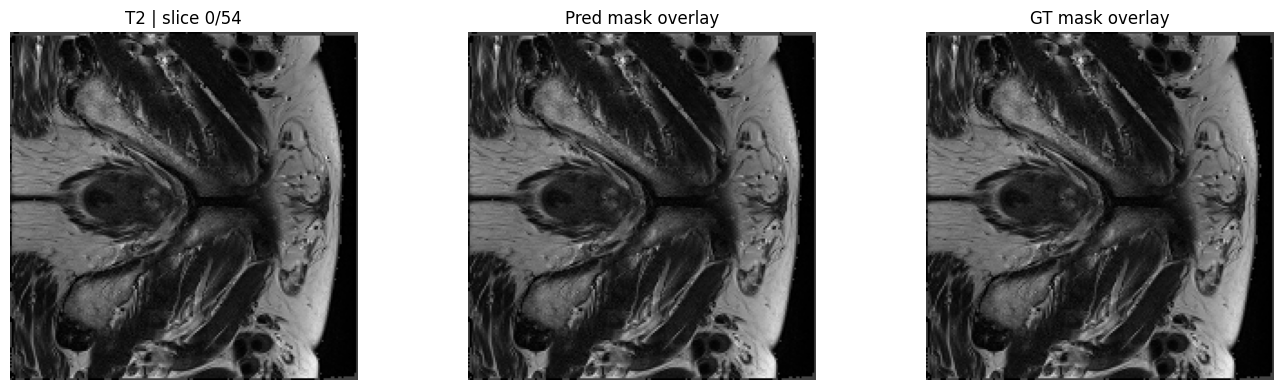

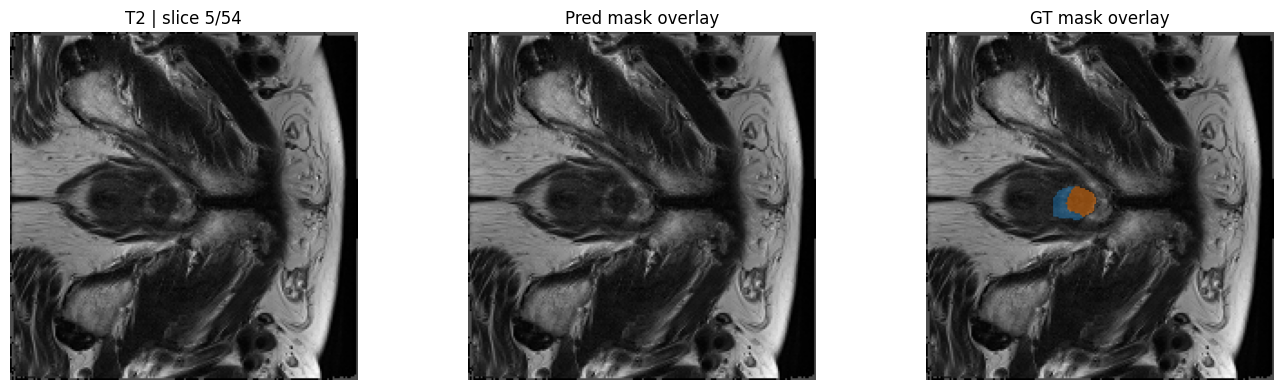

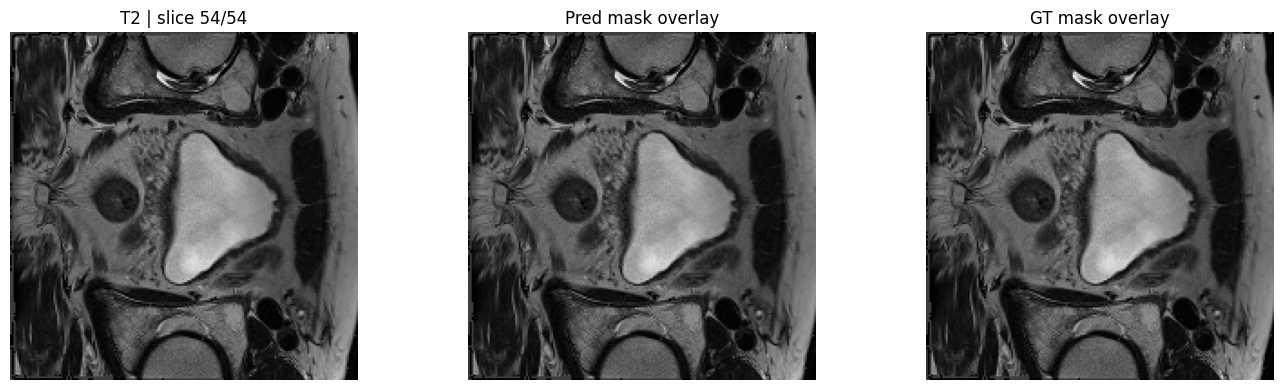

In [16]:
# Simple slice viewer
axis_map = {"Axial (z)": 2, "Coronal (y)": 1, "Sagittal (x)": 0}


def plot_slice(data: dict, axis_name: str = "Axial (z)", slice_idx: int = 0):
    axis = axis_map[axis_name]
    vol = data["t2"]
    pred = data["pred"]
    gt = data["gt"]
    max_idx = vol.shape[axis] - 1
    slice_idx = int(np.clip(slice_idx, 0, max_idx))

    if axis == 0:
        img_slice = vol[slice_idx, :, :]
        pred_slice = pred[slice_idx, :, :]
        gt_slice = gt[slice_idx, :, :]
    elif axis == 1:
        img_slice = vol[:, slice_idx, :]
        pred_slice = pred[:, slice_idx, :]
        gt_slice = gt[:, slice_idx, :]
    else:
        img_slice = vol[:, :, slice_idx]
        pred_slice = pred[:, :, slice_idx]
        gt_slice = gt[:, :, slice_idx]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_slice, cmap="gray")
    axes[0].set_title(f"T2 | slice {slice_idx}/{max_idx}")

    axes[1].imshow(img_slice, cmap="gray")
    axes[1].imshow(np.ma.masked_where(pred_slice == 0, pred_slice), cmap=mask_cmap, alpha=0.5, vmin=0, vmax=2)
    axes[1].set_title("Pred mask overlay")

    axes[2].imshow(img_slice, cmap="gray")
    axes[2].imshow(np.ma.masked_where(gt_slice == 0, gt_slice), cmap=mask_cmap, alpha=0.5, vmin=0, vmax=2)
    axes[2].set_title("GT mask overlay")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Widgets
def make_viewer():
    subject_dd = widgets.Dropdown(options=val_ids, description="Subject")
    axis_dd = widgets.Dropdown(options=list(axis_map.keys()), value="Axial (z)", description="Plane")
    slice_slider = widgets.IntSlider(value=0, min=0, max=400, step=1, description="Slice")

    def _render(change=None):
        idx = val_ids.index(subject_dd.value)
        data = infer_subject(idx)
        plot_slice(data, axis_dd.value, slice_slider.value)

    subject_dd.observe(_render, names="value")
    axis_dd.observe(_render, names="value")
    slice_slider.observe(_render, names="value")

    display(widgets.HBox([subject_dd, axis_dd, slice_slider]))
    _render()

make_viewer()

